In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 2  # Gpc
qS = 0.5
phiS = 1.0
qK = 1.0
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

# PAPER
# m1 = 1e6
# m2 = 10 
# a= 0.5
# p0=9.5
# e0=0.2
# xI0 = 1.0 #keep equatorial
# # below are randomly chosen
# dist = 0.25  # Gpc
# qS = 0.5
# phiS = 1.0
# qK = 1.0
# phiK = phiS + np.pi/3
# Phi_phi0 = 0.
# Phi_theta0 = 0.
# Phi_r0 = 0.

params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [2]:
print("Generating waveform...")
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [3]:
h

array([-1.49502327e-22+1.45014733e-21j, -3.25693343e-22+1.41844236e-21j,
       -4.91046471e-22+1.36810900e-21j, ...,
        1.70110358e-21+5.76601333e-22j,  1.54223510e-21+9.09142397e-22j,
        1.30989646e-21+1.21584230e-21j])

In [4]:
h_real = h.real
h_real

array([-1.49502327e-22, -3.25693343e-22, -4.91046471e-22, ...,
        1.70110358e-21,  1.54223510e-21,  1.30989646e-21])

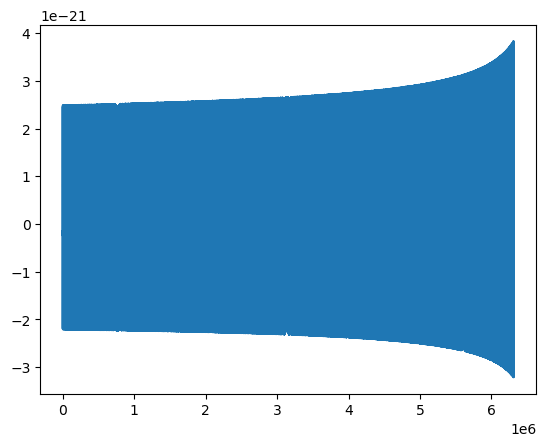

In [5]:
plt.plot(h_real.get())
plt.show()

In [6]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [7]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [8]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362022393

In [9]:
p_arr, e_arr

(array([11.7       , 11.69999959, 11.69999917, ...,  5.62159697,
         5.62159237,  5.62158778]),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.12687824, 0.12687808,
        0.12687792]))

In [10]:
len(p_arr)

6311629

In [11]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.01971368776220821, 0.019108341687235263, 0.015451845941009939],
 [0.019713689337112185, 0.019108343183883658, 0.01545184703159573],
 [0.019713690912014286, 0.019108344680520625, 0.015451848122172113],
 [0.019713692486921473, 0.019108346177170728, 0.015451849212759373],
 [0.019713694061824667, 0.01910834767382069, 0.015451850303346351],
 [0.019713695636715104, 0.01910834917045682, 0.01545185139392199],
 [0.01971369721163589, 0.019108350667113083, 0.015451852484513974],
 [0.019713698786543627, 0.019108352163756902, 0.015451853575095858],
 [0.019713700361440087, 0.01910835366039379, 0.01545185466567214],
 [0.01971370193633806, 0.019108355157038372, 0.015451855756254467],
 [0.01971370351124129, 0.019108356653691774, 0.015451856846843819],
 [0.019713705086149946, 0.019108358150337634, 0.015451857937427298],
 [0.01971370666105235, 0.01910835964698086, 0.015451859028008398],
 [0.01971370823597391, 0.01910836114363829, 0.015451860118600969],
 [0.019713709810886857, 0.019108362640287625, 0.

In [12]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [54]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-5, 2)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [55]:
len(modes), len(mode_freqs)

(84, 84)

In [56]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-5, 2)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-5, 2)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [57]:
modes_l2

[(2, -2, -5),
 (2, -2, -4),
 (2, -2, -3),
 (2, -2, -2),
 (2, -2, -1),
 (2, -2, 0),
 (2, -2, 1),
 (2, -1, -5),
 (2, -1, -4),
 (2, -1, -3),
 (2, -1, -2),
 (2, -1, -1),
 (2, -1, 0),
 (2, -1, 1),
 (2, 0, -5),
 (2, 0, -4),
 (2, 0, -3),
 (2, 0, -2),
 (2, 0, -1),
 (2, 0, 0),
 (2, 0, 1),
 (2, 1, -5),
 (2, 1, -4),
 (2, 1, -3),
 (2, 1, -2),
 (2, 1, -1),
 (2, 1, 0),
 (2, 1, 1),
 (2, 2, -5),
 (2, 2, -4),
 (2, 2, -3),
 (2, 2, -2),
 (2, 2, -1),
 (2, 2, 0),
 (2, 2, 1)]

In [58]:
modes_l3

[(3, -3, -5),
 (3, -3, -4),
 (3, -3, -3),
 (3, -3, -2),
 (3, -3, -1),
 (3, -3, 0),
 (3, -3, 1),
 (3, -2, -5),
 (3, -2, -4),
 (3, -2, -3),
 (3, -2, -2),
 (3, -2, -1),
 (3, -2, 0),
 (3, -2, 1),
 (3, -1, -5),
 (3, -1, -4),
 (3, -1, -3),
 (3, -1, -2),
 (3, -1, -1),
 (3, -1, 0),
 (3, -1, 1),
 (3, 0, -5),
 (3, 0, -4),
 (3, 0, -3),
 (3, 0, -2),
 (3, 0, -1),
 (3, 0, 0),
 (3, 0, 1),
 (3, 1, -5),
 (3, 1, -4),
 (3, 1, -3),
 (3, 1, -2),
 (3, 1, -1),
 (3, 1, 0),
 (3, 1, 1),
 (3, 2, -5),
 (3, 2, -4),
 (3, 2, -3),
 (3, 2, -2),
 (3, 2, -1),
 (3, 2, 0),
 (3, 2, 1),
 (3, 3, -5),
 (3, 3, -4),
 (3, 3, -3),
 (3, 3, -2),
 (3, 3, -1),
 (3, 3, 0),
 (3, 3, 1)]

<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/2094324045.py:52: SyntaxWarning: invalid escape sequence '\e'
  label = f'$(\ell={ell}, n={n})$'


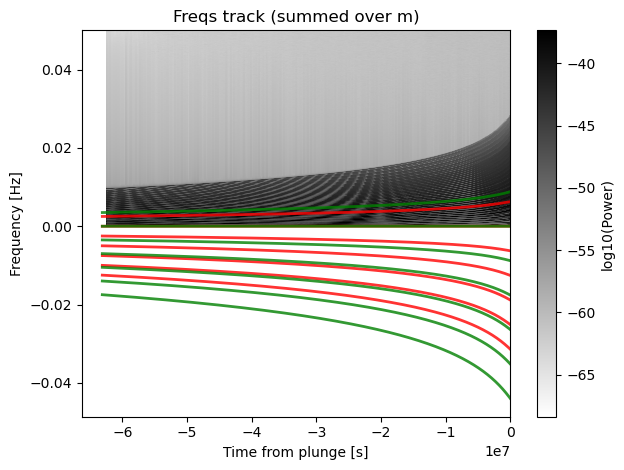

In [59]:
fs = 1.0 / dt  # Sampling frequency
nperseg = 2**16  # Window size for STFT
noverlap = nperseg * 3 // 4

f, t, Sxx = signal.spectrogram(h_real.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)

t_years = t / YRSID_SI
T_total = len(h_real) * dt / YRSID_SI
t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

t_traj_years = t_arr - t_arr[-1] 

fig, ax = plt.subplots()
# 1. Align Time Units: Convert spectrogram time 't' to "seconds from plunge"
# Assuming 't' starts at 0 and goes to the end of the signal
t_spec_seconds = t - t[-1] 

# 2. Plot using the synchronized time axis
# Note: shading='gouraud' is faster and smoother than flat
pcm = ax.pcolormesh(t_spec_seconds, f, np.log10(Sxx), 
                    shading='gouraud', 
                    cmap='gray_r',  # 'gray_r' (reversed) often looks better for spectrograms
                    vmin=np.min(np.log10(Sxx)), 
                    vmax=np.max(np.log10(Sxx)))

# Move the spectrogram to the back so lines sit on top
pcm.set_zorder(-1) 

plt.colorbar(pcm, ax=ax, label='log10(Power)')

# plot each freqs
# colors = plt.cm.tab10(np.linspace(0, 1, len(modes)))

# for i in range(len(modes)):
#     ell, m, n = modes[i]
#     label = f'$(\ell={ell}, m={m}, n={n})$'
#     plt.plot(t_traj_years, mode_freqs[i], color=colors[i], linewidth=2, alpha=0.8, label=label)

from collections import defaultdict

# Sum frequencies for each (ell, n)
mode_groups = defaultdict(list)
for i, (ell, m, n) in enumerate(modes):
    mode_groups[(ell, n)].append(mode_freqs[i])
summed_freqs = {}
for (ell, n), freq_list in mode_groups.items():
    summed_freqs[(ell, n)] = np.sum(freq_list, axis=0)

# plot summed freqs
# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$(\ell={ell}, n={n})$'
    if ell == 2:
        col = 'red'
        lstyle = 'dashed'
    elif ell == 3:
        col = 'green'
        lstyle = 'dotted'
    plt.plot(t_traj_years, freq, color=col, linewidth=2, alpha=0.8, label=label)

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title('Freqs track (summed over m)')
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/2133443768.py:30: SyntaxWarning: invalid escape sequence '\e'
  label = f'$(\ell={ell}, m={m}, n={n})$'


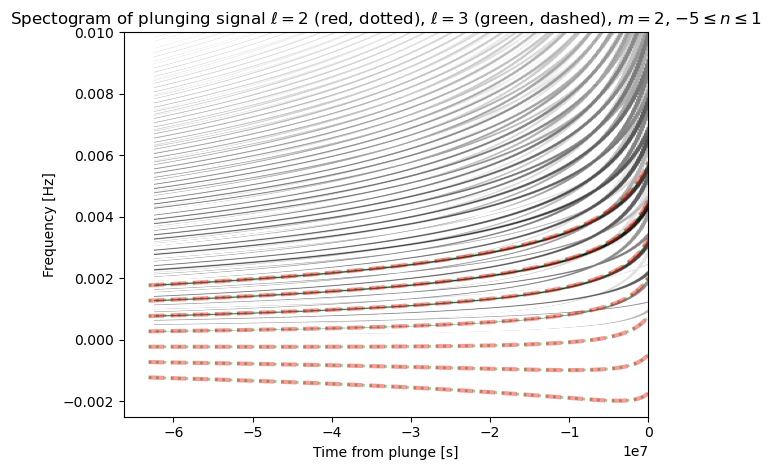

: 

In [ ]:
log_amp = np.log10(np.sqrt(Sxx))
max_val = np.max(log_amp)
# 4 ord of magnitude
vmin_val = max_val - 4
t_spec_seconds = t - t[-1] 

extent = [t_spec_seconds[0], t_spec_seconds[-1], f[0], f[-1]]
fig, ax = plt.subplots()
im = ax.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)

# plot each freqs

for i in range(len(modes)):
    ell, m, n = modes[i]
    if ell == 2:
        col = 'red'
        lstyle = 'dashed'
        linewidth=3
    elif ell == 3:
        col = 'green'
        lstyle = 'dotted'
        linewidth=2
    label = f'$(\ell={ell}, m={m}, n={n})$'
    if m == 2:
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=col,linewidth=linewidth, alpha=0.4, label=label)


plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title(r'Spectogram of plunging signal $\ell=2$ (red, dotted), $\ell=3$ (green, dashed), $m =2$, $-5 \leq n \leq 1$')
plt.ylim(-0.0025, 0.01)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [61]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

In [62]:
# nperseg = 2**16  
# noverlap = nperseg * 3 // 4  # 


f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)
f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)



/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/1645407287.py:5: UserWarning: Input data is complex, switching to return_onesided=False
  f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)
/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/1645407287.py:6: UserWarning: Input data is complex, switching to return_onesided=False
  f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)


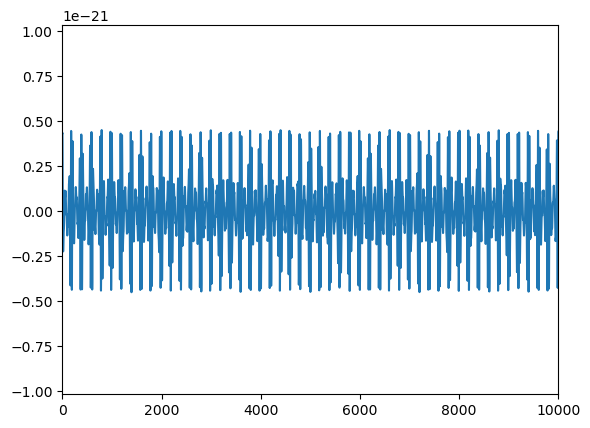

In [63]:
# plt.plot(h_l2.get().real)
plt.plot(h_l3.get().real)
plt.xlim(0,1e4)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/2340005177.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/var/tmp/pbs.515981.stdct-mgmt-02/ipykernel_1564627/2340005177.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\

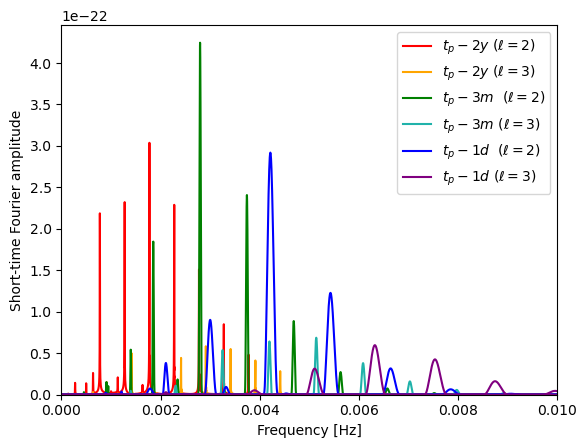

In [64]:
times_before_plunge = [2.0, 3/12, 1/365.25]  # 2y, 3m, 1d
colors_l2 = ['red', 'green', 'blue']
colors_l3 = ['orange', 'lightseagreen', 'purple']
labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
labels_l3 = ['$t_p - 2y$ ($\ell=3$)', '$t_p - 3m$ ($\ell=3$)', '$t_p - 1d$ ($\ell=3$)']

fig, ax = plt.subplots()

for time_bp, color_l2, color_l3, label_l2, label_l3 in zip(times_before_plunge, colors_l2, colors_l3, labels_l2, labels_l3):
    target_time = -time_bp
    idx = np.argmin(np.abs(t_years_adjusted - target_time))
    # amplitude = np.sqrt(Sxx[:, idx])
    amplitude_l2 = np.abs(Zxx_l2[:, idx])  # or np.sqrt(Sxx[:, idx]) if using spectrogram
    amplitude_l3 = np.abs(Zxx_l3[:, idx])  

    ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
    ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Short-time Fourier amplitude')
ax.set_xlim([0, 0.01])
ax.set_ylim([0, None]) 
ax.legend()

In [65]:
T,dt

(2.0, 10.0)

In [66]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)


In [67]:
snr_full = gwf.rhostat(h)
snr_full

array(261.16134971)

In [68]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(231.75779891)

In [69]:
p_l2 = gwf.rhostat(h_l2)/gwf.rhostat(h)*100
p_l2

array(88.74123187)

In [70]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(109.23054683)

In [71]:
p_l3 = gwf.rhostat(h_l3)/gwf.rhostat(h)*100
p_l3

array(41.82492814)

In [72]:
np.sqrt(snr_l2**2+snr_l3**2)/snr_full*100

array(98.10367398)